<a href="https://colab.research.google.com/github/prateek4ai/Test/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

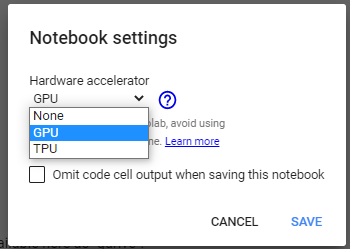

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


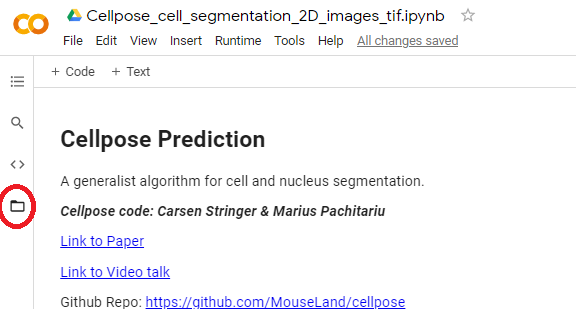

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

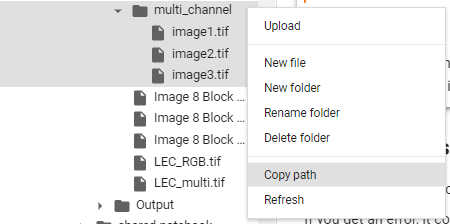

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [2]:
!uv pip install git+https://www.github.com/mouseland/cellpose.git
!uv pip install git+https://github.com/facebookresearch/dinov3.git

Using Python 3.12.13 environment at: /usr
Resolved 43 packages in 8.72s
Prepared 6 packages in 1.19s
Installed 6 packages in 10ms
 + cellpose==4.2.1.1 (from git+https://www.github.com/mouseland/cellpose.git@a54cb48849b7e225a81e8e43dcb042d42427f543)
 + fastremap==1.20.0
 + fill-voids==2.1.2
 + imagecodecs==2026.3.6
 + roifile==2026.2.10
 + segment-anything==1.0
Using Python 3.12.13 environment at: /usr
Resolved 49 packages in 3.18s
Prepared 5 packages in 471ms
Installed 5 packages in 11ms
 + dinov3==0.0.1 (from git+https://github.com/facebookresearch/dinov3.git@346f38fee679c56a6888f91c51670fae61d364e0)
 + ftfy==6.3.1
 + lightning-utilities==0.15.3
 + submitit==1.5.4
 + torchmetrics==1.9.0


Check GPU and instantiate model - will download weights.

In [3]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

### You can also use other pretrained models, like the DINO models
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino")
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino-vitb")

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-12 07:41:57,074 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-07-12 07:41:57,075 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-07-12 07:41:57,494 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-12 07:41:57,497 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-12 07:41:57,498 [core INFO] >>>> using GPU (CUDA)
2026-07-12 07:41:57,499 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam_v2" to /root/.cellpose/models/cpsam_v2



100%|██████████| 1.15G/1.15G [00:09<00:00, 130MB/s]


2026-07-12 07:42:11,196 [models INFO] >>>> loading model /root/.cellpose/models/cpsam_v2


In [6]:
from cellpose import io
!wget --no-check-certificate https://www.cellpose.org/static/data/rgb_3D.tif -O /content/rgb_3D.tif

--2026-07-12 07:43:16--  https://www.cellpose.org/static/data/rgb_3D.tif
Resolving www.cellpose.org (www.cellpose.org)... 35.173.69.207
Connecting to www.cellpose.org (www.cellpose.org)|35.173.69.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1712538 (1.6M) [image/tiff]
Saving to: ‘/content/rgb_3D.tif’

/content/rgb_3D.tif 100%[===================>]   1.63M  5.54MB/s    in 0.3s    

2026-07-12 07:43:17 (5.54 MB/s) - ‘/content/rgb_3D.tif’ saved [1712538/1712538]



Input directory with your images:

In [12]:
import os
os.makedirs("/content/sample_data_cp", exist_ok=True)
os.rename("/content/rgb_3D.tif", "/content/sample_data_cp/rgb_3D.tif")

dir = "/content/sample_data_cp"   # folder, not the file
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

image_ext = ".tif"

files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
rgb_3D.tif


In [15]:
# *** change to your google drive folder path ***
dir = "/content/sample_data_cp"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
rgb_3D.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [16]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

2026-07-12 07:46:59,824 [io INFO] reading tiff with 150 planes


100%|██████████| 150/150 [00:00<00:00, 9060.15it/s]

your image has shape: (75, 2, 75, 75). Assuming channel dimension is last with 75 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a third stain (described below), you can run segmentation with all channels.

In [17]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]

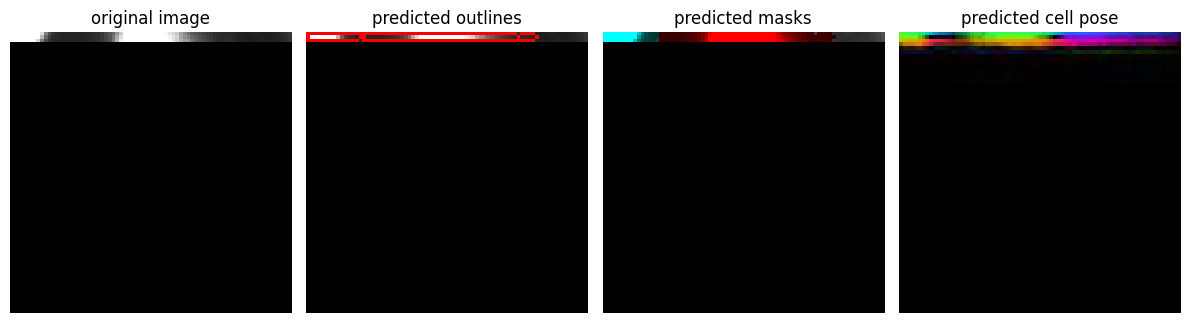

In [20]:
z = 37  # pick a mid-stack slice, adjust as needed

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels[z], masks[z], flows[0][z])
plt.tight_layout()
plt.show()

In [24]:
print("img shape:", img.shape)
print("img_selected_channels shape:", img_selected_channels.shape)

# count non-zero mask pixels per z-plane
counts = [(masks[z] > 0).sum() for z in range(masks.shape[0])]
for z, c in enumerate(counts):
    print(z, c)

best_z = int(np.argmax(counts))
print("best z-slice:", best_z, "with", counts[best_z], "mask pixels")

img shape: (75, 2, 75, 75)
img_selected_channels shape: (75, 2, 75, 75)
0 227
1 240
2 238
3 223
4 0
5 0
6 0
7 0
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0
16 0
17 0
18 0
19 0
20 0
21 0
22 30
23 33
24 39
25 43
26 51
27 56
28 62
29 64
30 90
31 94
32 100
33 113
34 128
35 149
36 174
37 182
38 182
39 165
40 158
41 161
42 157
43 155
44 154
45 115
46 148
47 0
48 0
49 0
50 0
51 0
52 0
53 0
54 0
55 0
56 115
57 140
58 186
59 204
60 214
61 216
62 222
63 222
64 224
65 218
66 214
67 213
68 211
69 211
70 215
71 217
72 218
73 218
74 215
best z-slice: 1 with 240 mask pixels


skipping channel 2: only 2 channels available (valid indices: 0 to 1)
selected_channels: [0, 1]
img_selected_channels shape: (75, 75, 75, 2)


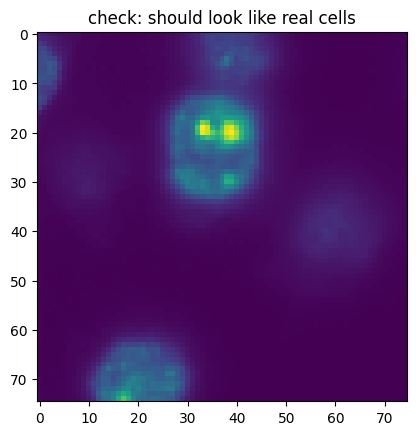

2026-07-12 07:59:13,374 [models WARNING] normalize_params['norm3D'] is True but do_3D is False and stitch_threshold=0, so setting to False
2026-07-12 07:59:43,905 [utils INFO] 100%|##########| 3/3 [00:30<00:00, 10.16s/it]
2026-07-12 07:59:43,906 [models INFO] network run in 30.48s
2026-07-12 07:59:47,489 [utils INFO] 100%|##########| 75/75 [00:03<00:00, 20.95it/s]
2026-07-12 07:59:47,489 [models WARNING] 3D stack used, but stitch_threshold=0 and do_3D=False, so masks are made per plane only
2026-07-12 07:59:47,490 [models INFO] masks created in 3.58s
best z-slice: 51 with 2785 mask pixels


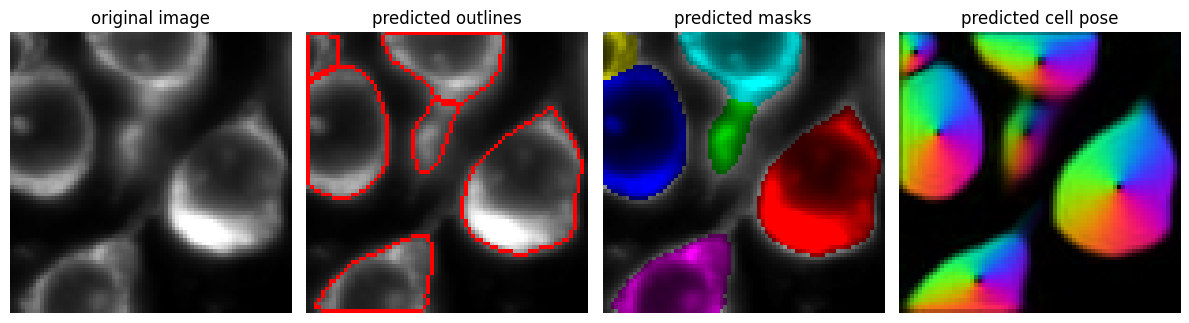

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import plot

# --- fix channel selection (axes are Z, Y, X, C after transpose) ---
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) >= img.shape[-1]:
    print(f"skipping channel {c}: only {img.shape[-1]} channels available (valid indices: 0 to {img.shape[-1]-1})")
    continue
  selected_channels.append(int(c))

print("selected_channels:", selected_channels)

img_selected_channels = np.zeros_like(img)
img_selected_channels[..., :len(selected_channels)] = img[..., selected_channels]

# sanity check
print("img_selected_channels shape:", img_selected_channels.shape)
plt.imshow(img_selected_channels[37, ..., 0])
plt.title("check: should look like real cells")
plt.show()

# --- run model ---
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32,
                                   channel_axis=-1,
                                   flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})

# --- find best z-slice with most mask pixels ---
counts = [(masks[z] > 0).sum() for z in range(masks.shape[0])]
best_z = int(np.argmax(counts))
print("best z-slice:", best_z, "with", counts[best_z], "mask pixels")

# --- plot ---
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels[best_z], masks[best_z], flows[0][best_z])
plt.tight_layout()
plt.show()

2026-07-12 08:00:26,864 [models WARNING] normalize_params['norm3D'] is True but do_3D is False and stitch_threshold=0, so setting to False
2026-07-12 08:00:54,727 [utils INFO] 100%|##########| 3/3 [00:27<00:00,  9.27s/it]
2026-07-12 08:00:54,728 [models INFO] network run in 27.82s
2026-07-12 08:00:54,730 [utils INFO] 0%|          | 0/75 [00:00<?, ?it/s]
2026-07-12 08:00:54,731 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,735 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,736 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,738 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,739 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,742 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,743 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,745 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,747 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,748 [dynamics INFO] No cell pixels found.
2026-07-12 08:00:54,750 

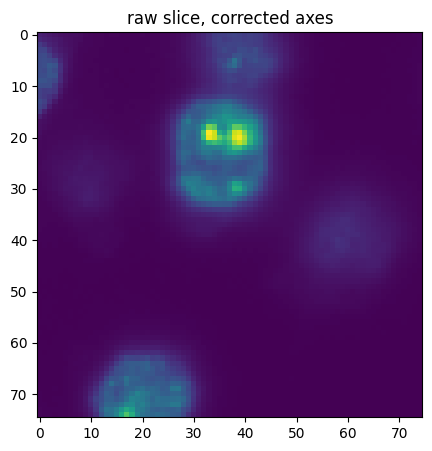

In [34]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

plt.figure(figsize=(5,5))
plt.imshow(img[37, :, :, 0])  # mid z-slice, channel 0
plt.title("raw slice, corrected axes")
plt.show()

In [25]:
print("before:", img.shape)
img = np.transpose(img, (0, 2, 3, 1))  # (Z,C,Y,X) -> (Z,Y,X,C)
print("after:", img.shape)

before: (75, 2, 75, 75)
after: (75, 75, 75, 2)


In [35]:
masks, flows, styles = model.eval(img_selected_channels, batch_size=32,
                                   do_3D=True,
                                   flow_threshold=flow_threshold,
                                   cellprob_threshold=cellprob_threshold,
                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})

ValueError: z_axis must be specified for 3D images of ndim=3 or 4D images of ndim=4

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.name + "_masks" + masks_ext), masks[i])
    io.save_rois(masks[i], f)